# Experiment Analysis

Load result JSONs from `results/` and plot training curves.

In [106]:
import json
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, ".")
from datasets import get_dataset

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.0,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Task data visualization

Plot training points and true label boundaries for the 1-D / 2-D synthetic tasks.
Pass the same `seed`, `noise`, and `train_fraction` you would use for an experiment
to see exactly the data the model trains on.

In [107]:
def _extract_numpy(dataset):
    """Pull (X, y) numpy arrays out of a TensorDataset or Subset."""
    from torch.utils.data import Subset, TensorDataset
    if isinstance(dataset, Subset):
        X_all, y_all = dataset.dataset.tensors
        idx = dataset.indices
        return X_all[idx].numpy(), y_all[idx].numpy()
    return dataset.tensors[0].numpy(), dataset.tensors[1].numpy()


def plot_task_data(task, seed=42, noise=0.0, train_fraction=1.0,
                   figsize=(8, 6), point_size=20):
    """Visualize training points and true boundaries for a synthetic task.

    Parameters
    ----------
    task : str
        One of 'simple_classification', 'simple_regression', 'bullseye'.
    seed, noise, train_fraction :
        Same values you pass to run_experiment so the data matches.
    """
    train_ds, test_ds, info = get_dataset(task, train_fraction, seed, noise)
    X_tr, y_tr = _extract_numpy(train_ds)

    fig, ax = plt.subplots(figsize=figsize)

    if task == "simple_regression":
        _plot_regression(ax, X_tr, y_tr, point_size)
    elif task == "simple_classification":
        _plot_simple_cls(ax, X_tr, y_tr, info, point_size)
    elif task == "bullseye":
        _plot_bullseye(ax, X_tr, y_tr, info, point_size)
    else:
        raise ValueError(f"Visualization not supported for '{task}'")

    title = task
    if noise > 0:
        title += f"  (noise={noise})"
    if train_fraction < 1.0:
        title += f"  (frac={train_fraction})"
    ax.set_title(title)
    if info["input_dim"] == 2:
        ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# ---- per-task helpers ------------------------------------------------

def _plot_regression(ax, X, y, ps):
    """1-D regression: training scatter + true sin(x) curve."""
    ax.scatter(X[:, 0], y[:, 0], s=ps, alpha=0.6, label="train points")
    xs = np.linspace(-3, 3, 300)
    ax.plot(xs, np.sin(xs), color="black", linewidth=1.5, label="y = sin(x)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, alpha=0.3)


def _plot_simple_cls(ax, X, y, info, ps):
    """2-D binary classification: scatter + Bayes-optimal boundary."""
    for c in range(info["num_classes"]):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=ps, alpha=0.7, label=f"class {c}")
    # Bayes boundary for equal-covariance Gaussians at (-1,-1) and (1,1)
    # is the line x0 + x1 = 0
    lo, hi = info["input_range"][0]
    ax.plot([lo, hi], [-lo, -hi], color="black", linewidth=1.5,
            linestyle="--", label="true boundary")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(*info["input_range"][1])
    ax.legend()
    ax.grid(True, alpha=0.3)


def _plot_bullseye(ax, X, y, info, ps):
    """2-D bullseye: scatter + true boundary circles."""
    for c in range(info["num_classes"]):
        mask = y == c
        lbl = "inner/outer (class 0)" if c == 0 else "ring (class 1)"
        ax.scatter(X[mask, 0], X[mask, 1], s=ps, alpha=0.6, label=lbl)
    theta = np.linspace(0, 2 * np.pi, 200)
    for r, name in [(1.0, "r=1"), (2.0, "r=2")]:
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                color="black", linewidth=1.5, linestyle="--", label=name)
    lo, hi = info["input_range"][0]
    ax.set_xlim(lo, hi)
    ax.set_ylim(*info["input_range"][1])
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend()
    ax.grid(True, alpha=0.3)

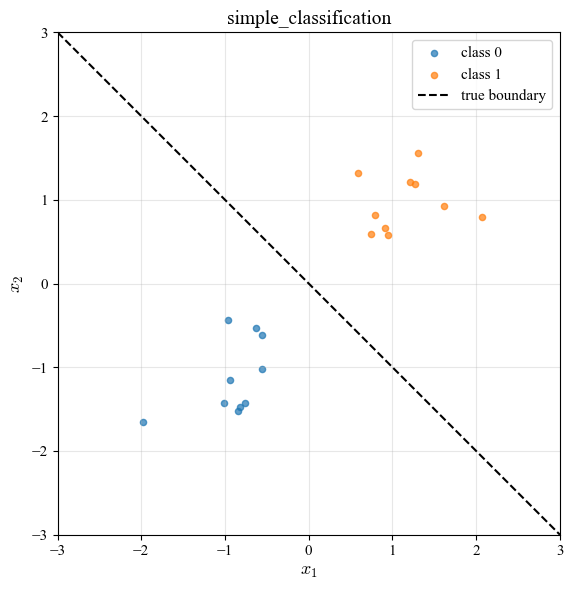

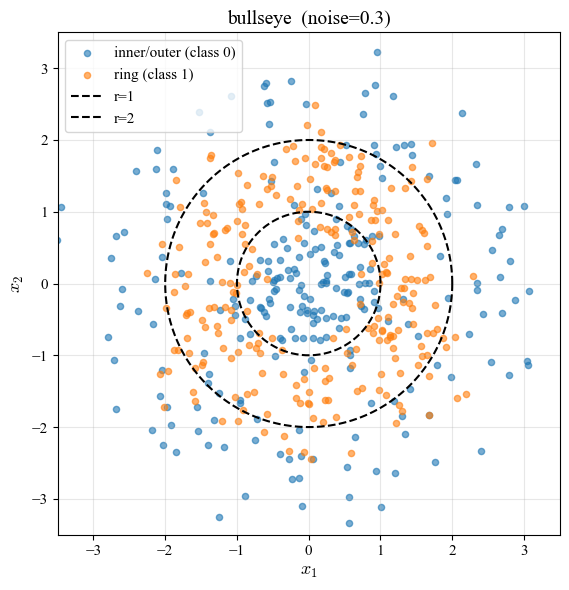

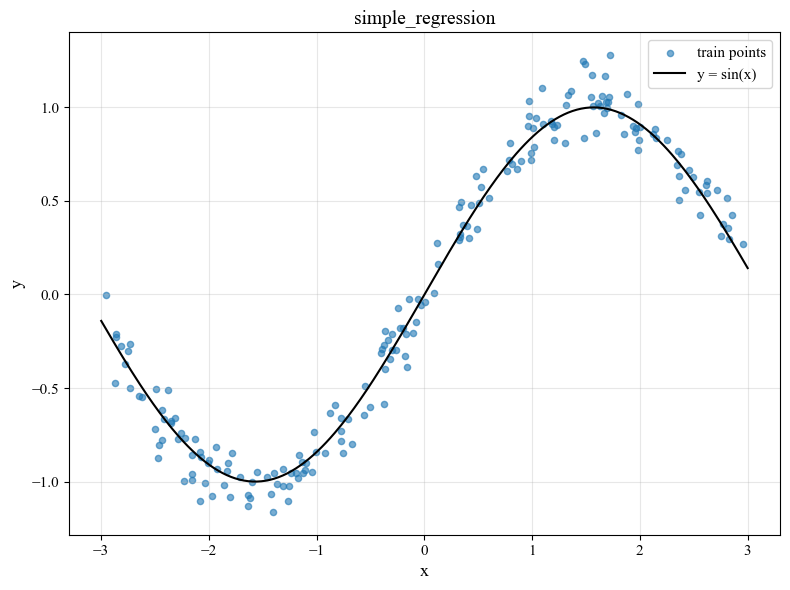

In [108]:
plot_task_data("simple_classification", noise=0.0)
plot_task_data("bullseye", noise=0.3)
plot_task_data("simple_regression", noise=0.0)

In [109]:
# Same tasks with noise for comparison
# plot_task_data("simple_classification", noise=0.5)
# plot_task_data("bullseye", noise=0.3)
# plot_task_data("simple_regression", noise=0.3)

---
## Training results

In [110]:
def load_results(pattern="results/*.json"):
    """Load all result JSON files matching *pattern*, sorted by filename."""
    results = []
    for path in sorted(glob.glob(pattern)):
        with open(path) as f:
            data = json.load(f)
        data["_path"] = path
        results.append(data)
    print(f"Loaded {len(results)} result file(s)")
    return results


def make_label(result):
    """Build a concise legend label from the experiment config."""
    c = result["config"]
    return (
        f"{c['optimizer']}/{c['loss']}  "
        f"w{c['width']} d{c['depth']}  "
        f"lr={c['lr']}"
    )


def filter_results(results, **kwargs):
    """Keep only results whose config matches every key=value pair.

    Example:
        filter_results(all_results, task="bullseye", optimizer="adam")
    """
    out = []
    for r in results:
        if all(r["config"].get(k) == v for k, v in kwargs.items()):
            out.append(r)
    print(f"Filtered to {len(out)} result(s)")
    return out

In [111]:
def plot_results(results, figsize_per_subplot=(14, 4)):
    """Plot Loss, Accuracy (if any), Linear Regions (if any), and Local Regions (if any).

    Each loaded experiment becomes one series on each subplot.
    """
    if not results:
        print("No results to plot.")
        return

    has_accuracy = any("train_accuracy" in r["results"] for r in results)

    def _method_counts(r):
        """Return {method: counts} for the result, handling old and new formats."""
        lr = r["results"].get("linear_regions")
        if lr is None:
            return {}
        counts = lr["counts"]
        if isinstance(counts, list):
            return {lr.get("method", "grid"): counts}
        return counts

    has_regions = any(
        any(m != "local" for m in _method_counts(r))
        for r in results
    )
    has_local = any(
        "local" in _method_counts(r)
        for r in results
    )

    n_plots = 1 + int(has_accuracy) + int(has_regions) + int(has_local)
    w, h = figsize_per_subplot
    fig, axes = plt.subplots(n_plots, 1, figsize=(w, h * n_plots),
                             squeeze=False)
    axes = axes.flatten()
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax_idx = 0

    # ---- Loss ----
    ax = axes[ax_idx]
    for i, r in enumerate(results):
        c = colors[i % len(colors)]
        label = make_label(r)
        epochs = range(1, len(r["results"]["train_loss"]) + 1)
        ax.plot(epochs, r["results"]["train_loss"],
                color=c, label=f"{label} (train)")
        ax.plot(epochs, r["results"]["test_loss"],
                color=c, linestyle="--", label=f"{label} (test)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    ax_idx += 1

    # ---- Accuracy ----
    if has_accuracy:
        ax = axes[ax_idx]
        for i, r in enumerate(results):
            if "train_accuracy" not in r["results"]:
                continue
            c = colors[i % len(colors)]
            label = make_label(r)
            epochs = range(1, len(r["results"]["train_accuracy"]) + 1)
            ax.plot(epochs, r["results"]["train_accuracy"],
                    color=c, label=f"{label} (train)")
            ax.plot(epochs, r["results"]["test_accuracy"],
                    color=c, linestyle="--", label=f"{label} (test)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title("Accuracy")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)
        ax_idx += 1

    # ---- Linear Regions (non-local methods) ----
    if has_regions:
        ax = axes[ax_idx]
        _APPROX_METHODS = {"pairwise"}
        _METHOD_LINESTYLES = ["-", "--", ":", "-."]
        for i, r in enumerate(results):
            mc = {m: c for m, c in _method_counts(r).items() if m != "local"}
            if not mc:
                continue
            color = colors[i % len(colors)]
            label = make_label(r)
            lr_epochs = r["results"]["linear_regions"]["epochs"]
            for j, (method, counts) in enumerate(mc.items()):
                ls = _METHOD_LINESTYLES[j % len(_METHOD_LINESTYLES)]
                suffix = f" ({method} avg)" if method in _APPROX_METHODS else f" ({method})"
                ax.plot(lr_epochs, counts, color=color, linestyle=ls,
                        marker="o", markersize=4, label=f"{label}{suffix}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Linear Regions")
        ax.set_title("Linear Regions")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)
        ax_idx += 1

    # ---- Linear Regions (local method) ----
    if has_local:
        ax = axes[ax_idx]
        for i, r in enumerate(results):
            mc = _method_counts(r)
            if "local" not in mc:
                continue
            color = colors[i % len(colors)]
            label = make_label(r)
            lr_epochs = r["results"]["linear_regions"]["epochs"]
            ax.plot(lr_epochs, mc["local"], color=color,
                    marker="o", markersize=4, label=f"{label} (local avg)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Linear Regions")
        ax.set_title("Linear Regions (local)")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Loaded 5 result file(s)


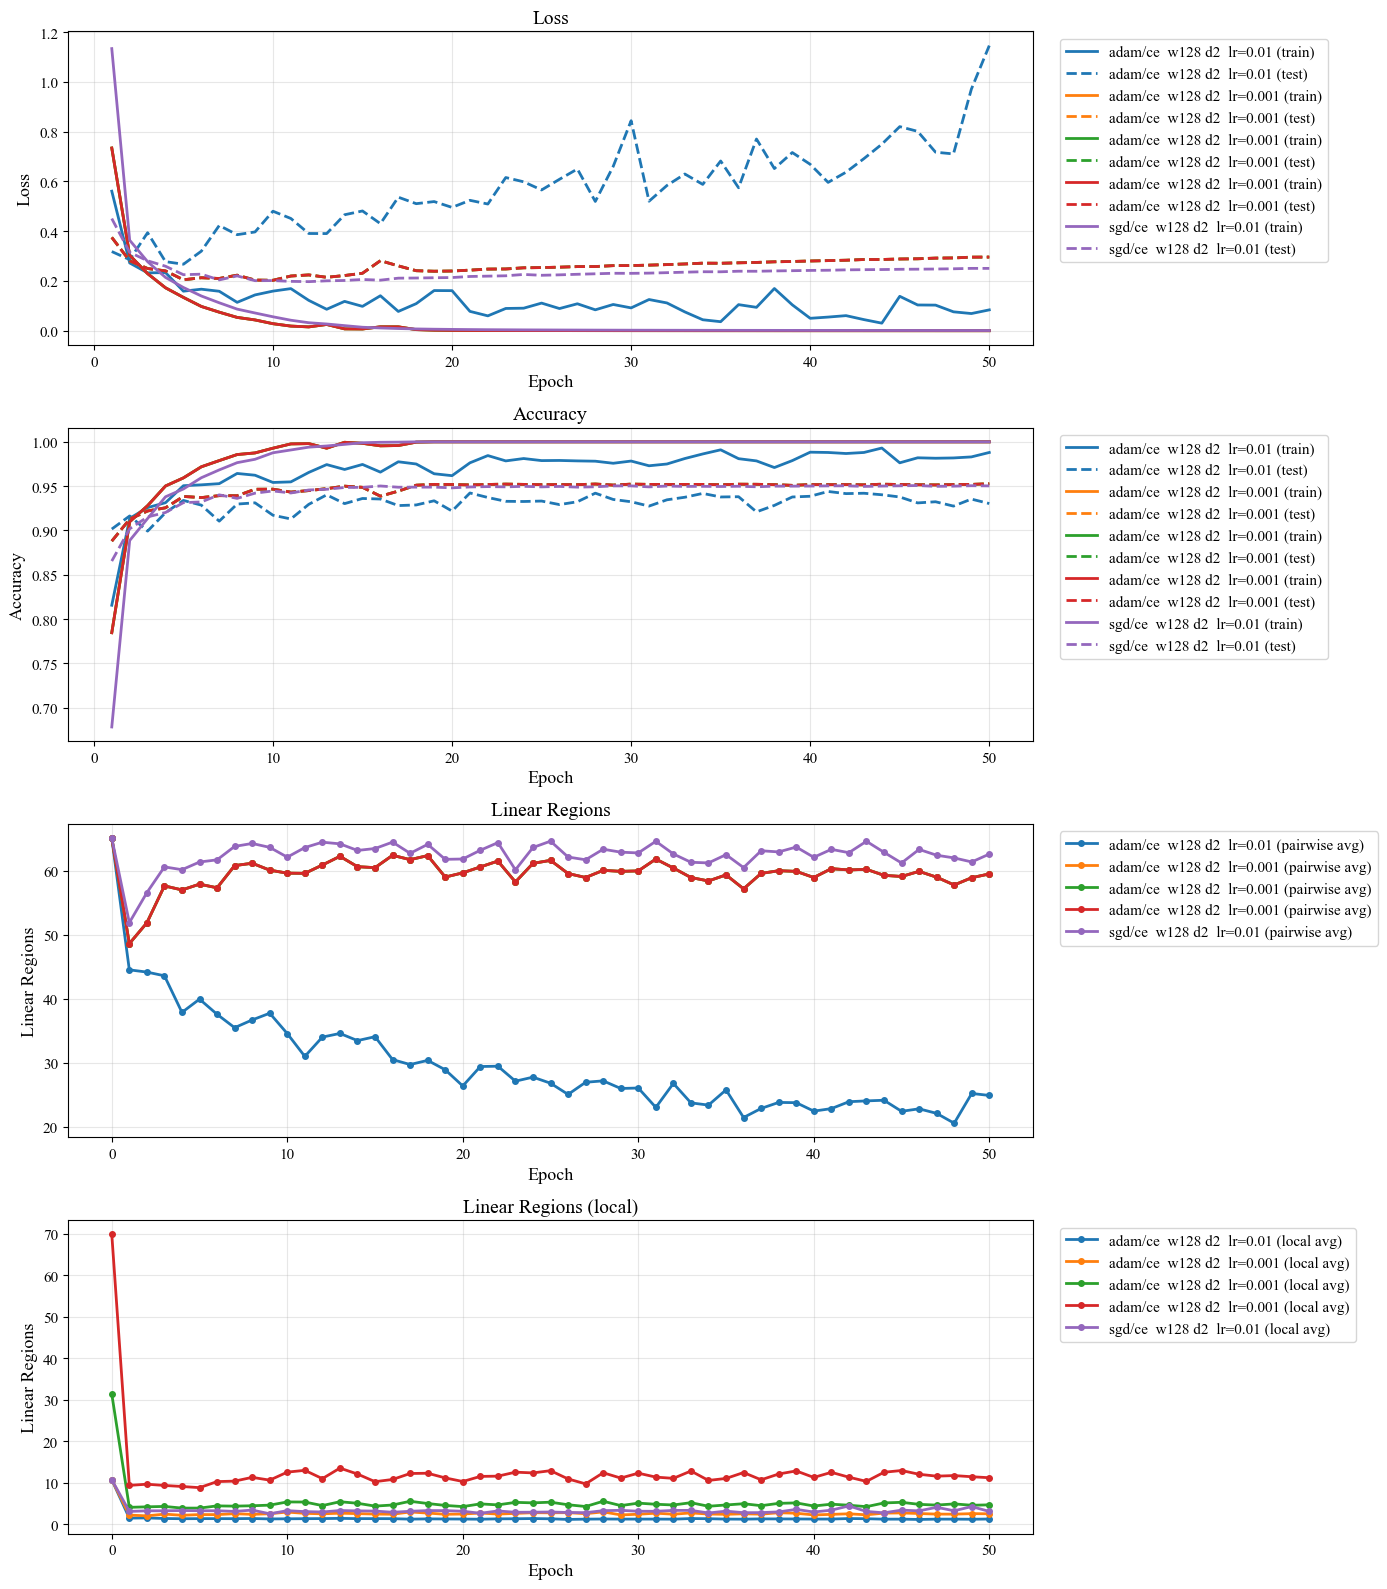

In [115]:
all_results = load_results("results_mnist/*.json")
plot_results(all_results)

### Filtered example

Pass any config keys to `filter_results` to narrow the set.

In [113]:
# Example: show only bullseye experiments run with Adam
# subset = filter_results(all_results, task="bullseye", optimizer="adam")
# plot_results(subset)